# Package

In [22]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from eda_utils import plot_reg_and_kde_grid, plot_corr_heatmap

# ----------------------------
# Feature Store
# ----------------------------
from feast import FeatureStore

import itertools
from scipy.stats import pearsonr

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load

In [2]:
# --------------------------------------------------
# Init Feast
# --------------------------------------------------
REPO_PATH = (
    Path.cwd().parent.parent
    / "2_data_processing"
    / "feature_store"
    / "feast_repo"
    / "feature_repo"
)

store = FeatureStore(repo_path=str(REPO_PATH))

# --------------------------------------------------
# Définir univers temporel
# --------------------------------------------------
dates = pd.date_range(
    start="1960-01-01",
    end="2025-09-01",
    freq="MS",
)

# --------------------------------------------------
# Series IDs (option 1 : explicite, OK pour maintenant)
# --------------------------------------------------
series_ids = [
    "BUSLOANS","CPIAUCSL","DPCERA3M086SBEA","INDPRO",
    "M2SL","OILPRICEX","RPI","SP500","TB3MS","UNRATE","USREC",
]

entity_df = pd.MultiIndex.from_product(
    [series_ids, dates],
    names=["series_id", "date"],
).to_frame(index=False)

# --------------------------------------------------
# Récupération Feast
# --------------------------------------------------
df_stationary = store.get_historical_features(
    entity_df=entity_df,
    features=["stationary_value:value"],
).to_df()

# --------------------------------------------------
# LONG → WIDE
# --------------------------------------------------
df_wide = (
    df_stationary
    .rename(columns={"stationary_value__value": "value"})
    .pivot(index="date", columns="series_id", values="value")
    .sort_index()
)

df = df_wide.copy()

df.head()

Using date as the event timestamp. To specify a column explicitly, please name it event_timestamp.


series_id,BUSLOANS,CPIAUCSL,DPCERA3M086SBEA,INDPRO,M2SL,OILPRICEX,RPI,SP500,TB3MS,UNRATE,USREC
date,,,,,,,,,,,
1960-01-01 00:00:00+00:00,0.011578,-0.006156,0.001204,0.091976,0.001323,0.0,0.020977,0.017909,0.30,-0.8,0.0
1960-02-01 00:00:00+00:00,0.011905,-0.003767,0.006009,0.076960,0.002007,0.0,0.014565,-0.025663,-0.19,-1.1,0.0
1960-03-01 00:00:00+00:00,-0.008356,-0.005455,0.021240,0.007959,0.001324,0.0,0.006250,-0.070857,-1.18,-0.2,0.0
1960-04-01 00:00:00+00:00,-0.009098,0.005090,0.033752,-0.025916,0.000634,0.0,0.006489,-0.040442,-1.12,0.0,0.0
1960-05-01 00:00:00+00:00,-0.000359,0.003383,0.009040,-0.018119,0.003977,0.0,0.007747,-0.010090,-0.67,0.0,1.0


In [3]:
df

series_id,BUSLOANS,CPIAUCSL,DPCERA3M086SBEA,INDPRO,M2SL,OILPRICEX,RPI,SP500,TB3MS,UNRATE,USREC
date,,,,,,,,,,,
1960-01-01 00:00:00+00:00,0.011578,-0.006156,0.001204,0.091976,0.001323,0.000000,0.020977,0.017909,0.30,-0.8,0.0
1960-02-01 00:00:00+00:00,0.011905,-0.003767,0.006009,0.076960,0.002007,0.000000,0.014565,-0.025663,-0.19,-1.1,0.0
1960-03-01 00:00:00+00:00,-0.008356,-0.005455,0.021240,0.007959,0.001324,0.000000,0.006250,-0.070857,-1.18,-0.2,0.0
1960-04-01 00:00:00+00:00,-0.009098,0.005090,0.033752,-0.025916,0.000634,0.000000,0.006489,-0.040442,-1.12,0.0,0.0
1960-05-01 00:00:00+00:00,-0.000359,0.003383,0.009040,-0.018119,0.003977,0.000000,0.007747,-0.010090,-0.67,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2025-05-01 00:00:00+00:00,0.044487,-0.007941,0.007758,0.000360,0.004820,-0.162581,0.008190,-0.038448,0.03,0.2,0.0
2025-06-01 00:00:00+00:00,0.035593,-0.000435,0.002578,0.005179,0.004174,0.026151,0.001403,0.059087,0.03,0.0,0.0
2025-07-01 00:00:00+00:00,-0.001303,0.001775,0.005014,0.001050,-0.001062,0.249194,-0.003535,0.159259,0.04,0.0,0.0


In [4]:
nan_dates = df.index[df.isna().any(axis=1)]

print(nan_dates[:20])   # premières dates
print("Nombre total :", len(nan_dates))

DatetimeIndex(['2025-09-01 00:00:00+00:00'], dtype='datetime64[ns, UTC]', name='date', freq=None)
Nombre total : 1


In [5]:
df = df.loc[: "2025-08-31"].copy()

In [6]:
df_train = df[df.index.year < 1990]
df_test = df.loc[df.index.difference(df_train.index)]

In [7]:
# Variables explicatives
X_train = df_train.drop("UNRATE", axis=1)
X_test = df_test.drop("UNRATE", axis=1)

# 1-Etude de la coorélation bivariée entre variables

d:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


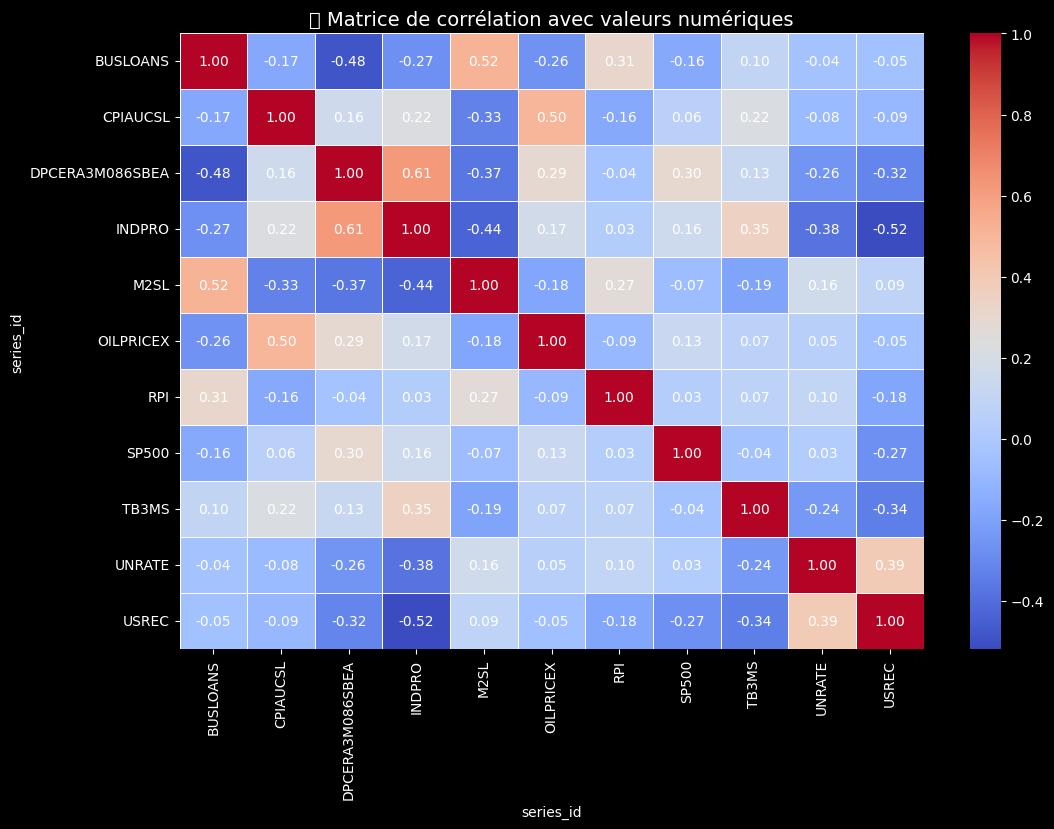

In [8]:
# Style sombre (fond noir global)
plt.style.use("dark_background")

plt.figure(figsize=(12, 8))

# Heatmap
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.7,
    cbar=True,
    annot_kws={"color": "white"}  # chiffres lisibles sur fond sombre
)

# Titre
plt.title("📌 Matrice de corrélation avec valeurs numériques", fontsize=14, color="white")

# Axe en blanc
plt.xticks(color="white")
plt.yticks(color="white")

plt.show()

# Test de significativité

In [9]:
# Test de significativité de coorélation
results = []
for var1, var2 in itertools.combinations(df.columns, 2):
    r, p = pearsonr(df_test[var1], df_test[var2])
    results.append({
        "Variable_1": var1,
        "Variable_2": var2,
        "Correlation": r,
        "p_value": p,
        "Significatif_5pct": "Oui" if p < 0.05 else "Non"
    })

df_corr_sig = pd.DataFrame(results).sort_values(by="Correlation", ascending=False).reset_index(drop=True)

In [10]:
df_corr_sig.head()

,Variable_1,Variable_2,Correlation,p_value,Significatif_5pct
0,DPCERA3M086SBEA,INDPRO,0.749029,3.526202e-78,Oui
1,BUSLOANS,M2SL,0.676013,1.859328e-58,Oui
2,CPIAUCSL,OILPRICEX,0.600218,3.058270e-43,Oui
3,DPCERA3M086SBEA,OILPRICEX,0.395856,1.652240e-17,Oui
4,BUSLOANS,RPI,0.357864,2.236442e-14,Oui


In [11]:
df_corr_sig["Significatif_5pct"].value_counts()

Significatif_5pct
Oui    45
Non    10
Name: count, dtype: int64

# Commentaire
Le test de significativité de corrélation entre les variables explicatives a montré que 31 paires de variables sont corrélées linéairement entre elles. La vraie question maintenant est de savoir si plus de deux variables sont corrélées entre elles.

## VIF (Variance Inflation Factor)

Pour chaque variable explicative \(X_j\) :

$$
\mathrm{VIF}_j=\frac{1}{1-R_j^2}
$$

La multicolinéarité apparaît lorsque plusieurs variables explicatives sont fortement corrélées entre elles.

In [18]:
# ============================================================
# Segments temporels
# ============================================================
segments = [
    ("1990-01-01", "1999-12-31", "1990-1999"),
    ("2000-01-01", "2008-12-31", "2000-2008"),
    ("2008-01-01", "2019-12-31", "2008-2019"),
    ("2020-01-01", None,         "2020-fin"),
]

# ============================================================
# Fonction VIF
# ============================================================
def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    X_clean = X.dropna().copy()

    if X_clean.shape[1] < 2:
        raise ValueError("Need at least 2 features for VIF.")

    vif_values = [
        variance_inflation_factor(X_clean.values, i)
        for i in range(X_clean.shape[1])
    ]

    return pd.DataFrame({
        "feature": X_clean.columns,
        "VIF": vif_values
    })

# ============================================================
# VIF par segments
# ============================================================
vif_results = []

for start, end, label in segments:

    df_seg = df.loc[start:] if end is None else df.loc[start:end]
    X_seg = df_seg.copy()

    vif_seg = compute_vif(X_seg)
    vif_seg["period"] = label

    vif_results.append(vif_seg)

# ============================================================
# VIF global ALL après 1990
# ============================================================
df_all_post1990 = df.loc["1990-01-01":].copy()

vif_all = compute_vif(df_all_post1990)
vif_all["period"] = "ALL_1990-fin"

vif_results.append(vif_all)

# ============================================================
# Tableau final
# ============================================================
df_vif_all = pd.concat(vif_results, ignore_index=True)

vif_pivot = df_vif_all.pivot(
    index="feature",
    columns="period",
    values="VIF"
)

# ordre colonnes
col_order = [
    "ALL_1990-fin",
    "1990-1999",
    "2000-2008",
    "2008-2019",
    "2020-fin"
]
vif_pivot = vif_pivot[col_order]

# ⭐ TRI PAR ALL_1990-fin
vif_pivot = vif_pivot.sort_values(
    by="ALL_1990-fin",
    ascending=False
)

print(vif_pivot.round(2))

period           ALL_1990-fin  1990-1999  2000-2008  2008-2019  2020-fin
feature                                                                 
DPCERA3M086SBEA          3.49       3.83       1.97       2.04      9.22
INDPRO                   3.47       3.33       2.69       2.77     13.35
BUSLOANS                 3.00       1.16       1.15       1.58     10.60
M2SL                     2.38       1.22       1.47       1.89      8.51
OILPRICEX                1.80       1.78       1.95       3.11      4.28
CPIAUCSL                 1.72       1.59       1.89       3.17      3.43
USREC                    1.66       1.24       2.64       3.71      1.79
UNRATE                   1.61       2.38       2.37       1.92      2.65
TB3MS                    1.45       2.45       2.17       2.27      1.93
RPI                      1.44       3.01       1.66       1.68      1.80
SP500                    1.35       1.98       2.17       2.28      2.15


Le VIF global après 1990 reste modéré. Cela montre qu’il n’y a pas de forte multicolinéarité sur l’ensemble de la période. La spécification des variables a été très bonne. 

En revanche, après 2020, plusieurs variables ont un VIF beaucoup plus élevé. Les indicateurs macroéconomiques évoluent donc plus ensemble dans cette période récente. Les coefficients des modèles changent, l'instabilité devient la règle et la préviion et difficile. 

Nous voulons mieux analyser d'abord ce changement de régime avant de donner une solution adéquate. 

# ACP

## Préparation de données

In [19]:
df_after_2019 = df[df.index.year > 2019]
df_after_2019 = df_after_2019[df_after_2019.index < "2020-08-31"]
df_after_2019.head()

series_id,BUSLOANS,CPIAUCSL,DPCERA3M086SBEA,INDPRO,M2SL,OILPRICEX,RPI,SP500,TB3MS,UNRATE,USREC
date,,,,,,,,,,,
2020-01-01 00:00:00+00:00,-0.017611,0.002364,0.011554,-0.003895,-0.004597,0.124819,0.008522,0.096150,-0.13,-0.4,0.0
2020-02-01 00:00:00+00:00,-0.009860,-0.001870,0.002722,-0.005545,-0.010275,-0.160517,0.009396,0.054041,-0.02,-0.3,0.0
2020-03-01 00:00:00+00:00,0.089473,-0.010687,-0.066898,-0.043124,0.020373,-0.768000,0.000208,-0.180398,-1.25,0.6,1.0
2020-04-01 00:00:00+00:00,0.222848,-0.019655,-0.187417,-0.177971,0.081796,-1.309636,0.104616,-0.171347,-1.38,11.1,1.0
2020-05-01 00:00:00+00:00,0.263542,-0.018692,-0.104006,-0.164925,0.131109,-0.449946,0.057029,-0.115569,-1.39,9.6,0.0


In [20]:
X_after_2019 = df_after_2019.drop("UNRATE", axis = 1)

In [23]:
# --- 2) Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_after_2019)

In [ ]:
# On installe l'ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [ ]:
# Pourcentage de variance expliquée par axe
print("Variance expliquée (%) :", pca.explained_variance_ratio_ * 100)

# Valeurs propres
print("Valeurs propres :", pca.explained_variance_)

Variance expliquée (%) : [7.86386087e+01 1.29730555e+01 3.73172877e+00 3.17607216e+00
 1.40332281e+00 6.95598333e-02 7.65224480e-03 1.67825007e-32]
Valeurs propres : [8.98726956e+00 1.48263491e+00 4.26483288e-01 3.62979676e-01
 1.60379749e-01 7.94969524e-03 8.74542262e-04 1.91800008e-33]


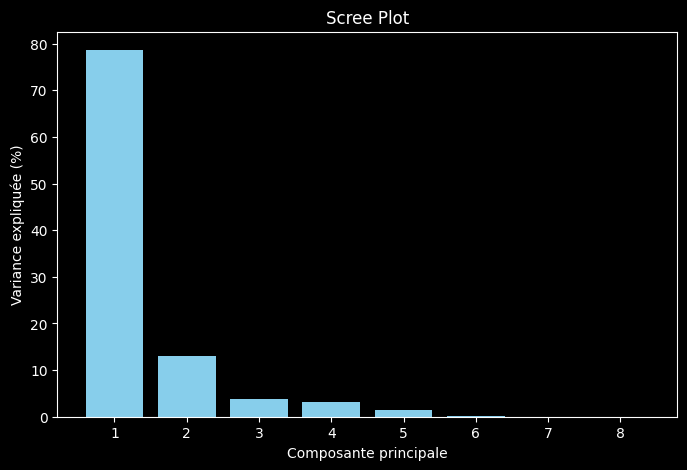

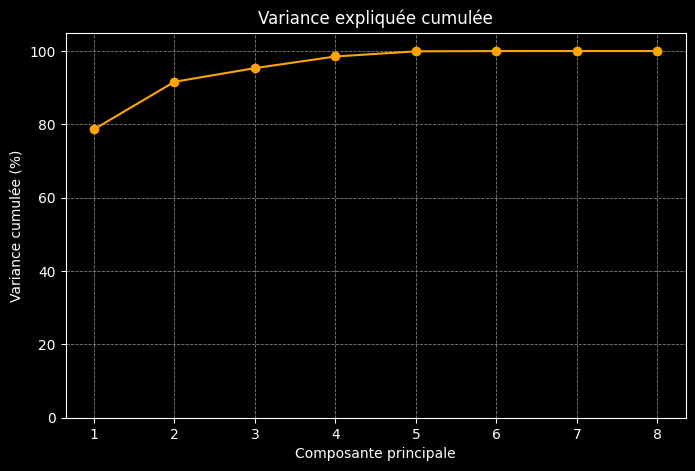

In [ ]:
# Image des valeurs propres
evr = pca.explained_variance_ratio_ * 100  # en %

# --- Thème DARK ---
plt.style.use("dark_background")

# --- Scree Plot ---
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(evr)+1), evr, color="skyblue")
plt.xlabel("Composante principale", color="white")
plt.ylabel("Variance expliquée (%)", color="white")
plt.title("Scree Plot", color="white")
plt.xticks(range(1, len(evr)+1), color="white")
plt.yticks(color="white")
plt.show()

# --- Variance cumulée ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(evr)+1), np.cumsum(evr), marker="o", color="orange")
plt.xlabel("Composante principale", color="white")
plt.ylabel("Variance cumulée (%)", color="white")
plt.title("Variance expliquée cumulée", color="white")
plt.xticks(range(1, len(evr)+1), color="white")
plt.yticks(color="white")
plt.ylim(0, 105)
plt.grid(color="gray", linestyle="--", linewidth=0.6)  # grille lisible sur fond noir
plt.show()

## ACP sur les 02 premiers axes

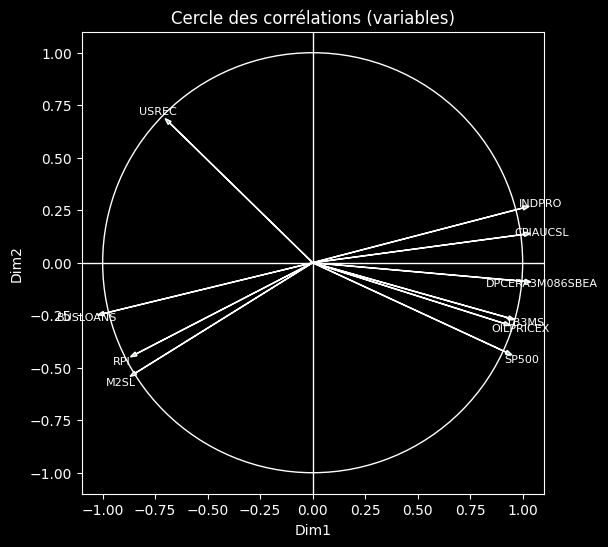

In [ ]:
# Cercle des corrélations (variables)
# Pour données standardisées, corr(var, axe) = composantes * sqrt(valeurs_propres)
features = getattr(X, "columns", [f"V{i+1}" for i in range(pca.components_.shape[1])])
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)   # (p x k)
corr = loadings[:, :2]

plt.figure(figsize=(6,6))
circle = plt.Circle((0, 0), 1, fill=False, linewidth=1)
plt.gca().add_artist(circle)
for i in range(corr.shape[0]):
    plt.arrow(0, 0, corr[i, 0], corr[i, 1], head_width=0.02, length_includes_head=True)
    plt.text(corr[i, 0]*1.05, corr[i, 1]*1.05, str(features[i]), ha='center', va='center', fontsize=8)
plt.axhline(0, linewidth=1); plt.axvline(0, linewidth=1)
plt.xlim(-1.1, 1.1); plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("Dim1"); plt.ylabel("Dim2")
plt.title("Cercle des corrélations (variables)")
plt.show()

# On va ajouter UNRATE comme variable supplémentaire dans l'ACP

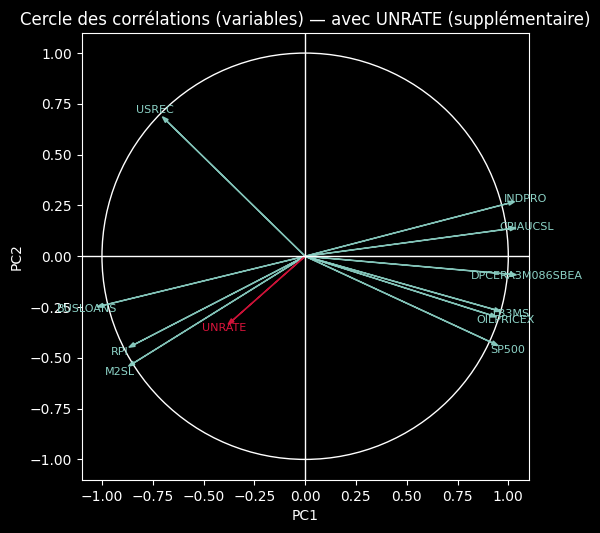

In [ ]:
# --- (on suppose que X = df_stationary_train sans 'UNRATE', déjà nettoyé comme pour ta PCA) ---
# Si tu n'as pas encore les 'scores' (coordonnées individus), on les (re)calcule :
from sklearn.preprocessing import StandardScaler
try:
    X_scaled  # existe déjà ?
except NameError:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

scores = pca.transform(X_scaled)  # (n_obs x n_PC)

# --- 1) Corrélations variables-axes (déjà dans ton code) ---
# loadings = pca.components_.T * np.sqrt(pca.explained_variance_)   # (p x k)
# corr = loadings[:, :2]  # coordonnées des variables sur (PC1, PC2)

# --- 2) Ajouter UNRATE comme variable SUPPLÉMENTAIRE ---
# On aligne UNRATE sur les mêmes lignes que X (et on retire les NaN éventuels côté UNRATE)
y_all = df_after_2019.loc[X_after_2019.index, "UNRATE"].astype(float)
mask  = y_all.notna()
y     = y_all[mask].values
scores_aligned = scores[mask.values, :]  # mêmes lignes

# Corrélation de UNRATE avec chaque axe (ici PC1, PC2)
r_unrate_pc1 = np.corrcoef(y, scores_aligned[:, 0])[0, 1]
r_unrate_pc2 = np.corrcoef(y, scores_aligned[:, 1])[0, 1]
unrate_coords = np.array([r_unrate_pc1, r_unrate_pc2])

# On étend les tableaux pour le tracé
features_ext = list(features) + ["UNRATE"]
corr_ext = np.vstack([corr, unrate_coords])

# --- 3) Tracé du cercle + UNRATE en couleur distincte ---
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
ax = plt.gca()
ax.add_artist(plt.Circle((0,0), 1, fill=False, linewidth=1))

for i in range(corr_ext.shape[0]):
    is_unrate = (features_ext[i] == "UNRATE")
    color = "crimson" if is_unrate else "C0"
    ax.arrow(0, 0, corr_ext[i, 0], corr_ext[i, 1],
             head_width=0.02, length_includes_head=True, color=color, alpha=0.9)
    ax.text(corr_ext[i, 0]*1.05, corr_ext[i, 1]*1.05, str(features_ext[i]),
            ha='center', va='center', fontsize=8, color=color)

ax.axhline(0, linewidth=1); ax.axvline(0, linewidth=1)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Cercle des corrélations (variables) — avec UNRATE (supplémentaire)")
plt.tight_layout()
plt.show()

### Synthèse

La longueur des axes de chaque variables dépasse le cercle. Les variables sont donc mieux présentées (80% par l'axe PC1).

L'ACP confirme et précise les résultats de VIF. La variable INDPRO (production indutrielle) et DPCE (conommation) portent la phère réel de l'économie (à droite). Et que Buloan(crédit bancaire) et M2L(création monétaire de la Fed) sont liées.   

Le taux de chômage américain (UNRATE) évolue en opposition aux indicateurs d’activité économique. Celà confirme son caractère contracyclique. A gauche, l'évolution de la création monétaire (M2SL) impacte positivement le chômage.

La multicolinéarité existe belle et bien dans les données. Elle est marquée par l'interrelation de l'offre globale, de la demande globale et ainsi la politique monétaire. 

Le VIF n’a pas détecté de multicolinéarité forte avant 2019. Toutefois, il reste important d’analyser la nature des relations entre les variables et le chômage. L’ACP permet d’observer si ces relations restent stables ou évoluent dans le temps. 

# 04 segments

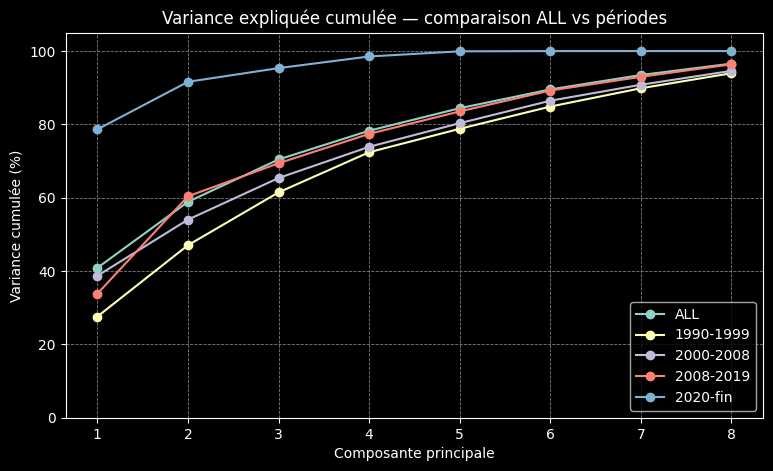

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.style.use("dark_background")

segments = [
    ("1990-01-01", "1999-12-31", "1990-1999"),
    ("2000-01-01", "2008-12-31", "2000-2008"),
    ("2008-01-01", "2019-12-31", "2008-2019"),
    ("2020-01-01", "2020-08-31", "2020-fin"),
]

def fit_pca(df_seg, target="UNRATE", include_target_in_circle=False):
    # include_target_in_circle=False => PCA sur X sans UNRATE (recommandé)
    # UNRATE pourra être projetée ensuite en "supplémentaire" si besoin
    X = df_seg.copy()
    if not include_target_in_circle:
        X = X.drop(columns=[target], errors="ignore")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA()
    pca.fit(X_scaled)

    return {"X": X, "scaler": scaler, "pca": pca, "evr": pca.explained_variance_ratio_}

def slice_df(df, start, end):
    return df[(df.index >= start) & (df.index <= end)].copy()

# ALL (même fenêtre que tes segments)
df_all = slice_df(df, "1990-01-01", "2020-08-31")
res_all = fit_pca(df_all, target="UNRATE", include_target_in_circle=False)

results = {"ALL": res_all}
for start, end, label in segments:
    results[label] = fit_pca(slice_df(df, start, end), target="UNRATE", include_target_in_circle=False)

# K composantes communes
K = min(8, min(len(r["evr"]) for r in results.values()))

# Plot cumulée (1 seul graphique)
plt.figure(figsize=(9, 5))
for label, r in results.items():
    cum = np.cumsum(r["evr"][:K]) * 100
    plt.plot(range(1, K+1), cum, marker="o", label=label)

plt.xlabel("Composante principale")
plt.ylabel("Variance cumulée (%)")
plt.title("Variance expliquée cumulée — comparaison ALL vs périodes")
plt.ylim(0, 105)
plt.grid(color="gray", linestyle="--", linewidth=0.6)
plt.legend()
plt.show()

La comparaison de la variance expliquée cumulée montre une structure stable entre 1990 et 2019. En revanche, la période 2020-fin présente une variance expliquée plus élevée dès les premiers axes. Ce qui veut dire une concentration plus forte de l’information autour de quelques facteurs dominants. La courbe ALL reflète une moyenne de ces différents régimes. 

d:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have

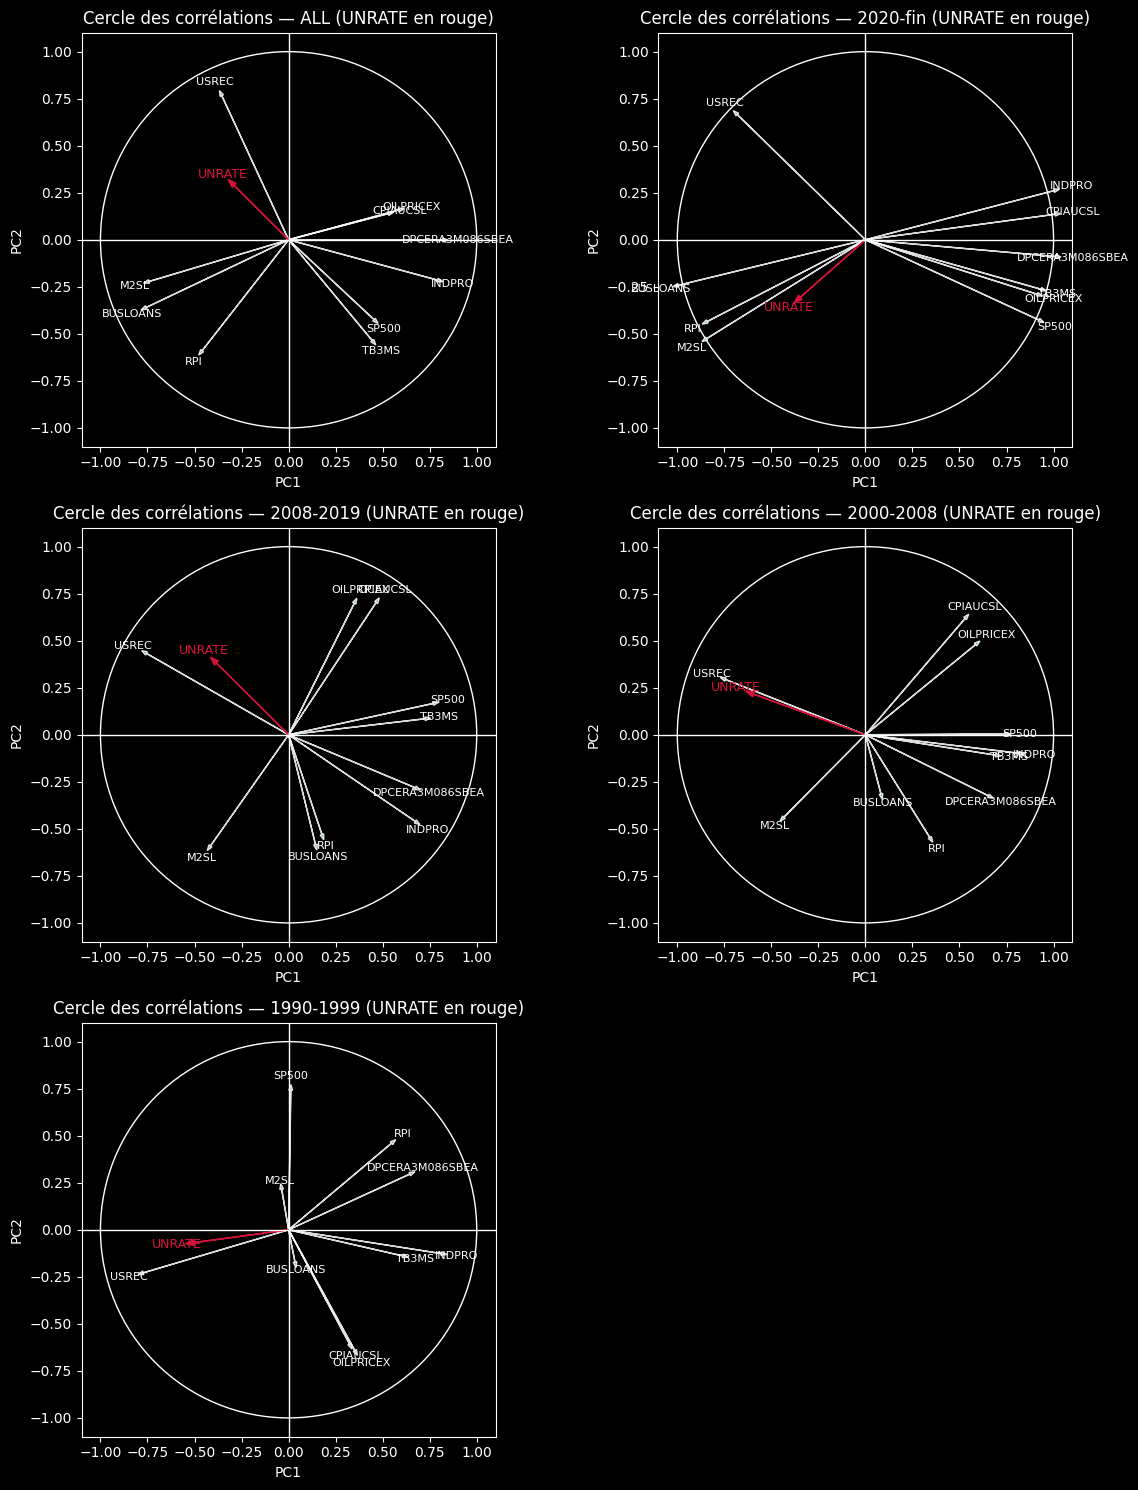

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import math

plt.style.use("dark_background")

# --------------------------
# UNRATE coords (supplémentaire) : corr(UNRATE, scores PC1/PC2)
# --------------------------
def unrate_coords_supplementary(df_seg, res, target="UNRATE"):
    # res["X"] = X sans UNRATE, index aligné sur df_seg
    X_seg = res["X"]
    scaler = res["scaler"]
    pca = res["pca"]

    # scores individus
    X_scaled = scaler.transform(X_seg.values)
    scores = pca.transform(X_scaled)  # (n_obs, n_pc)

    # aligner UNRATE
    y_all = df_seg.loc[X_seg.index, target].astype(float)
    mask = y_all.notna().values
    y = y_all.values[mask]
    scores_aligned = scores[mask, :]

    # corr UNRATE avec PC1, PC2
    r1 = np.corrcoef(y, scores_aligned[:, 0])[0, 1]
    r2 = np.corrcoef(y, scores_aligned[:, 1])[0, 1]
    return np.array([r1, r2])

# --------------------------
# Cercle des corrélations + UNRATE rouge
# --------------------------
def correlation_circle_with_unrate(df_seg, res, ax, title="", target="UNRATE"):
    pca = res["pca"]
    feature_names = list(res["X"].columns)

    # corr(var, PCk) = loading * sqrt(eigenvalue)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    corr = loadings[:, :2]  # (p,2)

    # coords UNRATE (supplémentaire)
    unrate_xy = unrate_coords_supplementary(df_seg, res, target=target)

    # cercle
    ax.add_artist(plt.Circle((0, 0), 1, fill=False, linewidth=1, color="white"))

    # variables X (bleu)
    for i, name in enumerate(feature_names):
        ax.arrow(0, 0, corr[i, 0], corr[i, 1],
                 head_width=0.02, length_includes_head=True, alpha=0.85)
        ax.text(corr[i, 0]*1.06, corr[i, 1]*1.06, str(name),
                ha="center", va="center", fontsize=8)

    # UNRATE (rouge)
    ax.arrow(0, 0, unrate_xy[0], unrate_xy[1],
             head_width=0.03, length_includes_head=True,
             color="crimson", alpha=0.95)
    ax.text(unrate_xy[0]*1.08, unrate_xy[1]*1.08, "UNRATE",
            ha="center", va="center", fontsize=9, color="crimson")

    ax.axhline(0, linewidth=1); ax.axvline(0, linewidth=1)
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title(title)

# --------------------------
# ORDRE DIACHRONIQUE INVERSÉ
# --------------------------
labels_order = ["ALL", "2020-fin", "2008-2019", "2000-2008", "1990-1999"]

# Pour chaque label, il faut le df_seg correspondant
# -> on reconstruit un dict df_by_label à partir de segments + ALL
def slice_df(df, start, end):
    if end is None:
        return df[df.index >= start].copy()
    return df[(df.index >= start) & (df.index <= end)].copy()

df_by_label = {}
# ALL : même fenêtre que tes segments (à adapter si besoin)
df_by_label["ALL"] = slice_df(df, "1990-01-01", "2020-08-31")

# segments
for start, end, lab in segments:
    df_by_label[lab] = slice_df(df, start, end)

# --------------------------
# Layout : 2 graph / ligne
# --------------------------
n_plots = len(labels_order)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

for i, label in enumerate(labels_order):
    r = i // n_cols
    c = i % n_cols
    ax = axes[r, c]

    df_seg = df_by_label[label]
    res = results[label]

    correlation_circle_with_unrate(
        df_seg=df_seg,
        res=res,
        ax=ax,
        title=f"Cercle des corrélations — {label} (UNRATE en rouge)",
        target="UNRATE"
    )

# enlever les cases vides
for j in range(n_plots, n_rows*n_cols):
    r = j // n_cols
    c = j % n_cols
    fig.delaxes(axes[r, c])

plt.tight_layout()
plt.show()

Certaines relations évoluent légèrement au fil du temps, notamment celles impliquant le revenu des ménages (DPCE) et la production industrielle (INDPRO), tandis que M2 et BUSLOANS deviennent davantage liés à la dynamique globale après 2019 alors que cette relation était peu visible auparavant.

Les changements les plus marqués concernent la relation entre l’indicateur de crise (USREC) et UNRATE. Le passage en récession ne suffit plus à anticiper le chômage comme dans les périodes précédentes. Par ailleurs, la structure de la multicolinéarité se transforme après 2019. Elle passe de relations principalement bivariées (pétrole–inflation, taux courts–marchés financiers) à des dimensions communes. La dimenion d'activité économique volatile à court terme à droite. Et la dimenion monétaire à gauche plus ou moins stable. 

A titre d'exception, le revenu des ménages évolue dans le même sens que le chômage après 2019. Ce phénomène s’explique par les politiques de soutien mises en place aux États-Unis durant la crise du COVID-19 (notamment le CARES Act), qui ont maintenu les revenus malgré la détérioration du marché du travail.

# Actions

- La Multicolinéarité après 2019 suggère d’utiliser Ridge. Avec une amélioration attendue surtout en période post-2019.

- L’évolution des relations entre variables impose une évaluation stricte en OOS pour donner une chance d'adaptation au modèle linéaire Rigide comme le Ridge.

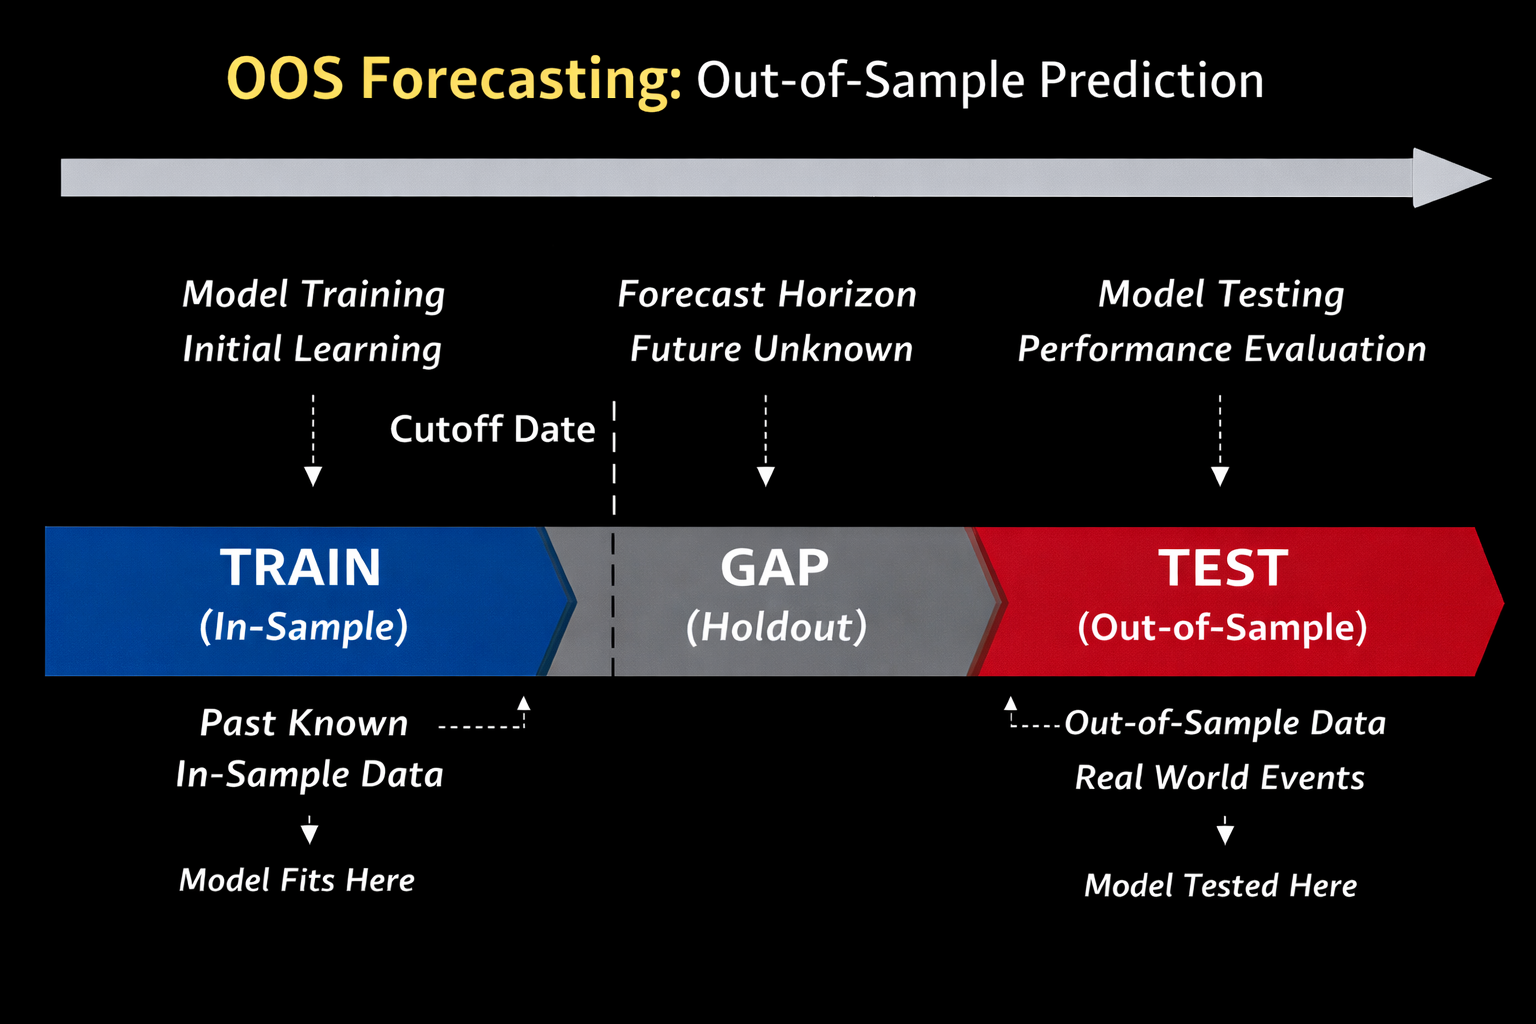